<a href="https://colab.research.google.com/github/DeisyUdec/semana3/blob/main/semana_3_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importación de librerias numpy,matplotlib, keras y layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

In [ ]:
#Se define los numeros aleatorios a trabajar para los arreglos de x y y
np.random.seed(0)
#se de
X = np.random.randn(250, 2)
y = (X[:, 0] * X[:, 1] > 0).astype(int)

In [ ]:
# se divide los datos para generar un entrenamiento teniendo
# teniendo en cuenta que la prueba de validación es de 20% y el entrenamiento de 80%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
#se crear el modelo con 2 capas secuenciales definiendo en cada capa la cantidad de nueronas y la activación del metodo de Relu y sigmoid
#y en la ultima capa se muestra la salida
def crear_modelo():
    model = keras.Sequential([
        layers.Dense(8, activation='relu', input_shape=(2,)),
        layers.Dense(4, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


In [ ]:
# se crea los metodos de optimizadores como SGD, Adam,  RMSprop ajustando el automatico del aprendizaje
optimizadores = {
    "SGD": keras.optimizers.SGD(learning_rate=0.01),
    "Adam": keras.optimizers.Adam(learning_rate=0.01),
    "RMSprop": keras.optimizers.RMSprop(learning_rate=0.01)
}


In [ ]:
#guarda los resultados
historiales = {}

In [ ]:
# se crea un ciclo para recorrer el optimizador
#objetivo crear, configuar, determinar  función de  error y la precisión
#
for nombre, opt in optimizadores.items():
    print(f"\nEntrenando con {nombre}...")

    modelo = crear_modelo()
    modelo.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
# enttrena el modelo definiendo la cantidad de veces que recorre
    history = modelo.fit(X_train, y_train,epochs=30,
        validation_data=(X_test, y_test),
        verbose=0
    )
# guarda resultados d eentrenamiento
    historiales[nombre] = history


Entrenando con SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Entrenando con Adam...

Entrenando con RMSprop...


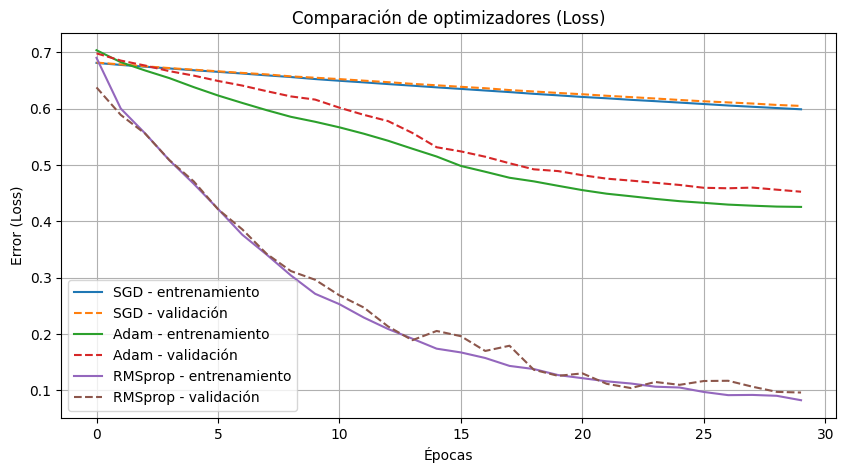

In [ ]:
# se crea una figura estadistica con los resultados del modelo entrenado
plt.figure(figsize=(10,5))

for nombre, history in historiales.items():
    plt.plot(history.history['loss'], label=f'{nombre} - entrenamiento')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'{nombre} - validación')

plt.title("Comparación de optimizadores (Loss)")
plt.xlabel("Épocas")
plt.ylabel("Error (Loss)")
plt.legend()
plt.grid()

plt.show()